In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import statsmodels.api as sm

In [2]:
df=pd.read_csv('data.csv',sep=',',decimal=',',index_col=0)

In [3]:
df.index=pd.to_datetime(df.index,unit='s')

In [4]:
df.columns
df

,T_ex,T_in,Power_Norm
Date_time,,,
2013-11-28 12:51:19,8,24.34512,26.718750
2013-11-28 13:25:32,8,24.31374,26.830357
2013-11-28 13:33:08,8,24.28236,26.316964
2013-11-28 13:44:06,8,24.34510,26.651786
2013-11-28 13:48:22,8,24.34510,26.250000
...,...,...,...
2014-12-17 15:46:27,9,22.39998,18.303571
2014-12-17 15:58:55,9,22.43136,18.750000
2014-12-17 16:04:58,9,22.43136,17.633929


In [5]:
df['deltaT']=df.T_in-df.T_ex

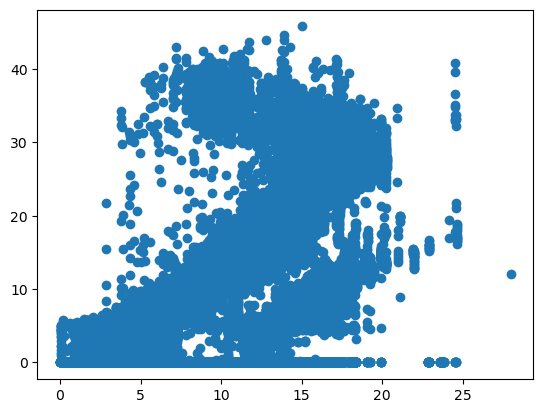

In [6]:
plt.figure()
plt.scatter(df.deltaT,df.Power_Norm)

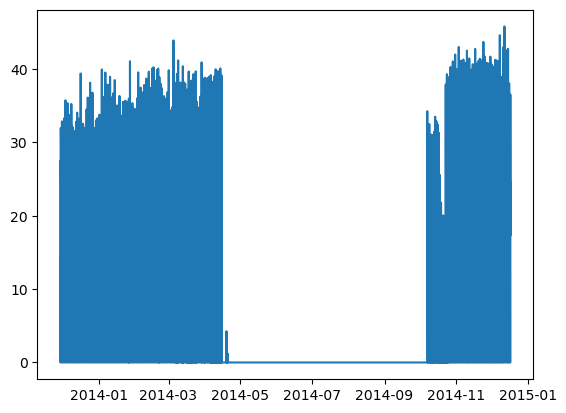

In [7]:
plt.plot(df.Power_Norm)

In [8]:
df=df.resample('H').mean()

/tmp/ipykernel_19619/1324031444.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df=df.resample('H').mean()


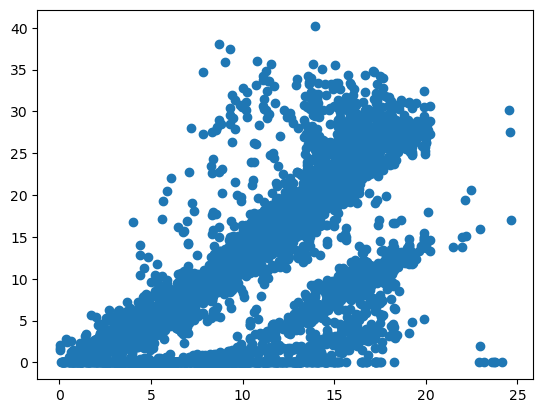

In [9]:
plt.scatter(df.deltaT,df.Power_Norm)

In [10]:
df=df.resample('D').mean()

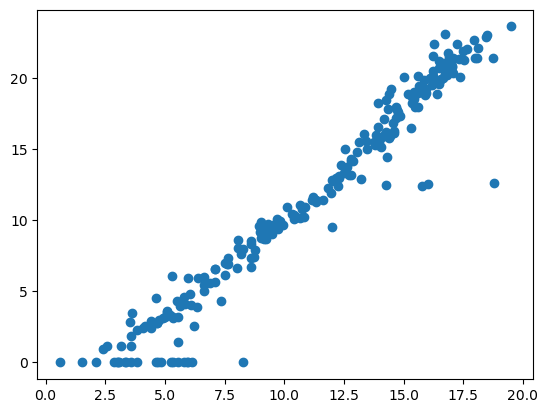

In [11]:
plt.scatter(df.deltaT,df.Power_Norm)

In [12]:
df=df.resample('W').mean()
df

,T_ex,T_in,Power_Norm,deltaT
Date_time,,,,
2013-12-01,6.107592,24.193650,21.502113,18.086057
2013-12-08,7.901723,24.050067,19.324201,16.148344
2013-12-15,7.102047,23.959962,20.945091,16.857914
2013-12-22,7.117571,23.939207,20.744520,16.821636
2013-12-29,8.465956,22.926249,18.291768,14.460293
2014-01-05,6.908848,23.136464,21.445353,16.227616
2014-01-12,9.092382,23.965532,17.840729,14.873150
2014-01-19,7.245037,24.124576,20.683496,16.879539
2014-01-26,9.384528,23.944887,16.463644,14.560359


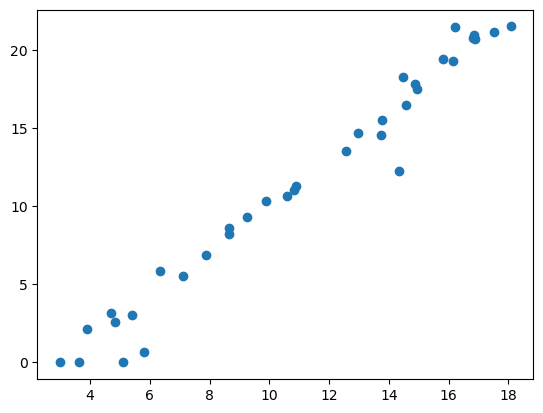

In [13]:
plt.scatter(df.deltaT,df.Power_Norm)


In [14]:
df=df.dropna()
df

,T_ex,T_in,Power_Norm,deltaT
Date_time,,,,
2013-12-01,6.107592,24.193650,21.502113,18.086057
2013-12-08,7.901723,24.050067,19.324201,16.148344
2013-12-15,7.102047,23.959962,20.945091,16.857914
2013-12-22,7.117571,23.939207,20.744520,16.821636
2013-12-29,8.465956,22.926249,18.291768,14.460293
2014-01-05,6.908848,23.136464,21.445353,16.227616
2014-01-12,9.092382,23.965532,17.840729,14.873150
2014-01-19,7.245037,24.124576,20.683496,16.879539
2014-01-26,9.384528,23.944887,16.463644,14.560359


In [15]:
model = sm.OLS(df.Power_Norm,sm.add_constant(df.deltaT))

In [16]:
results=model.fit()

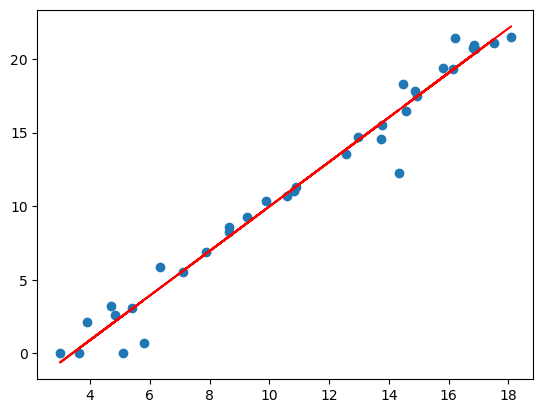

In [17]:
plt.plot(df.deltaT,results.predict(),'r')
plt.scatter(df.deltaT,df.Power_Norm)

In [18]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Power_Norm   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.971
Method:                 Least Squares   F-statistic:                     1129.
Date:                Mon, 25 Nov 2024   Prob (F-statistic):           4.21e-27
Time:                        22:13:23   Log-Likelihood:                -56.267
No. Observations:                  35   AIC:                             116.5
Df Residuals:                      33   BIC:                             119.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.1572      0.541     -9.539      0.000      -6.257      -4.057
deltaT         1.5136      0.045     33.602      0.000       1.422       1.605
==============================================================================
Omnibus:                       22.376   Durbin-Watson:                   1.951
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               35.659
Skew:                          -1.660   Prob(JB):                     1.81e-08
Kurtosis:                       6.664   Cond. No.                         31.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""